In [3]:
import pandas as pd
import numpy as np



In [4]:
df = pd.read_csv("GlobalWeatherRepository.csv")

print(df.shape)
print(df.head())


(122381, 41)
       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1                    66.2  

In [24]:
df.info()
df.describe()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122381 entries, 0 to 122380
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       122381 non-null  object 
 1   location_name                 122381 non-null  object 
 2   latitude                      122381 non-null  float64
 3   longitude                     122381 non-null  float64
 4   timezone                      122381 non-null  object 
 5   last_updated_epoch            122381 non-null  int64  
 6   last_updated                  122381 non-null  object 
 7   temperature_celsius           122381 non-null  float64
 8   temperature_fahrenheit        122381 non-null  float64
 9   condition_text                122381 non-null  object 
 10  wind_mph                      122381 non-null  float64
 11  wind_kph                      122381 non-null  float64
 12  wind_degree                   122381 non-nul

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [6]:
df.isnull().sum()


country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [16]:
df.to_csv("cleaned_global_weather.csv", index=False)


In [7]:
df = df.dropna()


In [7]:
df['country'].value_counts()




country
Bulgaria         1438
Indonesia        1259
Sudan            1256
Thailand         1255
Turkey           1255
                 ... 
Saudi Arabien       1
Bélgica             1
Turkménistan        1
火鸡                  1
Jemen               1
Name: count, Length: 211, dtype: int64

In [27]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day



In [11]:
df[['last_updated','year','month','day']].head()


,last_updated,year,month,day
0,2024-05-16 13:15:00,2024,5,16
1,2024-05-16 10:45:00,2024,5,16
2,2024-05-16 09:45:00,2024,5,16
3,2024-05-16 10:45:00,2024,5,16
4,2024-05-16 09:45:00,2024,5,16


In [15]:
df['hour'] = df['last_updated'].dt.hour
df[['last_updated','hour']].head()


,last_updated,hour
0,2024-05-16 13:15:00,13
1,2024-05-16 10:45:00,10
2,2024-05-16 09:45:00,9
3,2024-05-16 10:45:00,10
4,2024-05-16 09:45:00,9


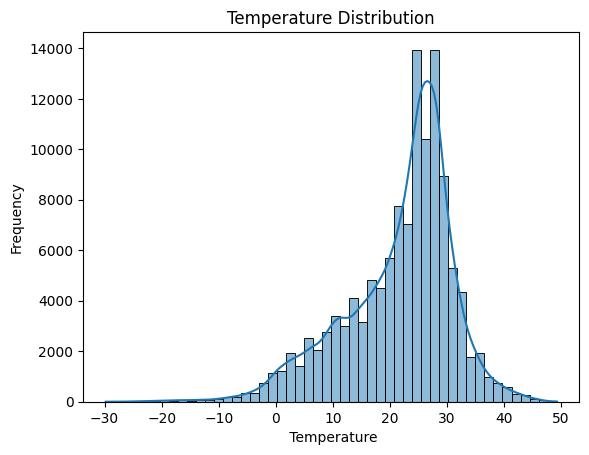

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['temperature_celsius'], bins=50, kde=True)
plt.title("Temperature Distribution")
plt.xlabel(" Temperature")
plt.ylabel("Frequency")
plt.show()

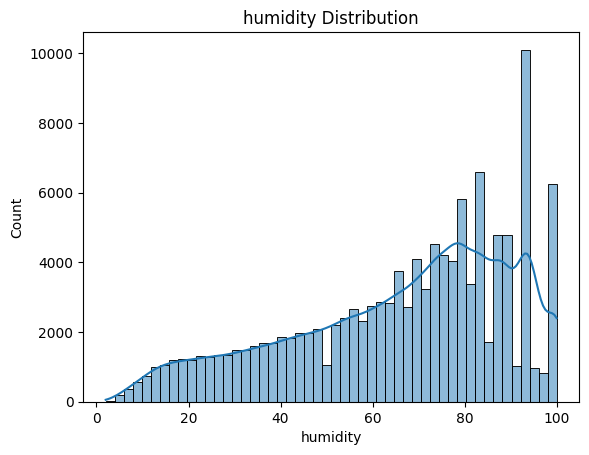

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['humidity'], bins=50, kde=True)
plt.title("humidity Distribution")
plt.show()

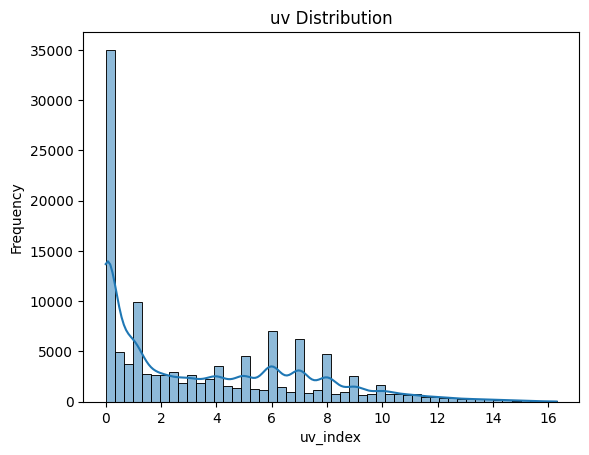

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['uv_index'], bins=50, kde=True)
plt.title("uv Distribution")
plt.ylabel("Frequency")
plt.show()

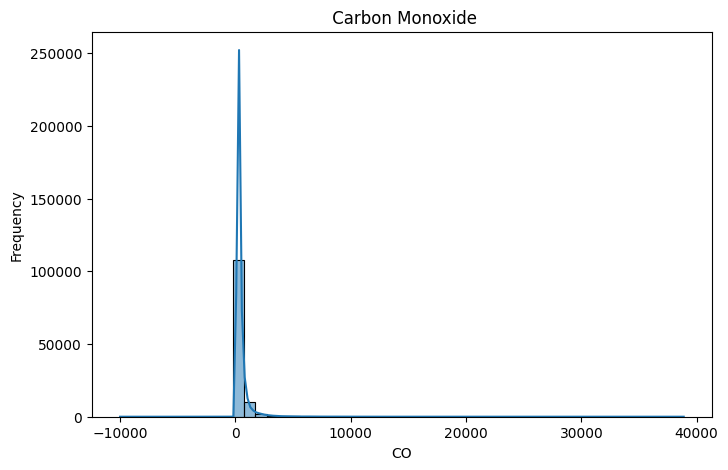

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['air_quality_Carbon_Monoxide'], bins=50, kde=True)
plt.title(" Carbon Monoxide")
plt.xlabel("CO")
plt.ylabel("Frequency")
plt.show()

In [23]:
df.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,122381.000000,122381.000000,1.223810e+05,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,...,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000,122381.000000
mean,19.190725,21.997413,1.743080e+09,21.712252,71.083800,8.079328,13.005993,169.333761,1014.096012,29.945601,...,18.310357,480.079131,59.182529,15.322134,10.751738,24.708329,49.435730,1.713567,2.642788,49.880700
std,24.428140,65.792360,1.570858e+07,9.514128,17.125307,7.408012,11.919024,103.395211,10.649795,0.314450,...,14.047696,788.092364,31.226457,24.424554,37.276251,38.074812,152.459282,0.952943,2.479213,35.120224
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,3.750000,-6.836100,1.729502e+09,16.300000,61.400000,4.000000,6.500000,81.000000,1010.000000,29.830000,...,10.400000,213.222000,39.000000,1.600000,1.050000,7.150000,10.150000,1.000000,1.000000,15.000000
50%,17.250000,23.316700,1.743068e+09,24.200000,75.500000,6.900000,11.200000,162.000000,1014.000000,29.930000,...,15.500000,305.250000,56.000000,5.400000,2.450000,14.350000,20.350000,1.000000,2.000000,50.000000
75%,40.400000,50.580000,1.756714e+09,28.100000,82.600000,11.200000,18.000000,256.000000,1018.000000,30.060000,...,24.300000,475.450000,75.000000,17.800000,8.695000,28.305000,42.365000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.770275e+09,49.200000,120.600000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


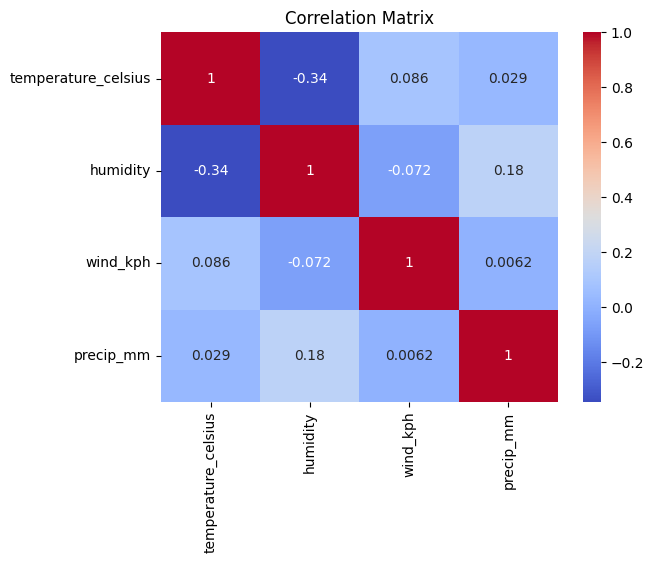

In [25]:
corr = df[['temperature_celsius','humidity','wind_kph','precip_mm']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

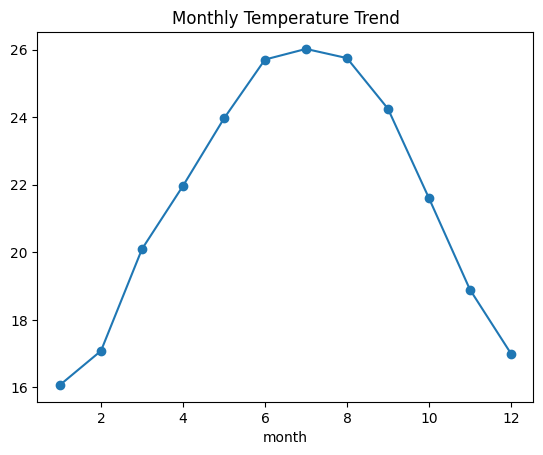

In [28]:
monthly_temp = df.groupby('month')['temperature_celsius'].mean()

monthly_temp.plot(kind='line', marker='o')
plt.title("Monthly Temperature Trend")
plt.show()

In [43]:
extreme_events = df[
    (df['temperature_celsius'] > 45) |
    (df['precip_mm'] > 200) |
    (df['wind_kph'] > 80)
]

In [44]:
extreme_rank = (
    extreme_events.groupby("country")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="extreme_event_count")
)

print(extreme_rank.head(10))

                country  extreme_event_count
0                Kuwait                   56
1                  Iraq                   53
2                 Qatar                   13
3          Saudi Arabia                   12
4  United Arab Emirates                    7
5              Djibouti                    5
6               Burundi                    2
7                  Oman                    2
8               Bahrain                    1
9              Barbados                    1


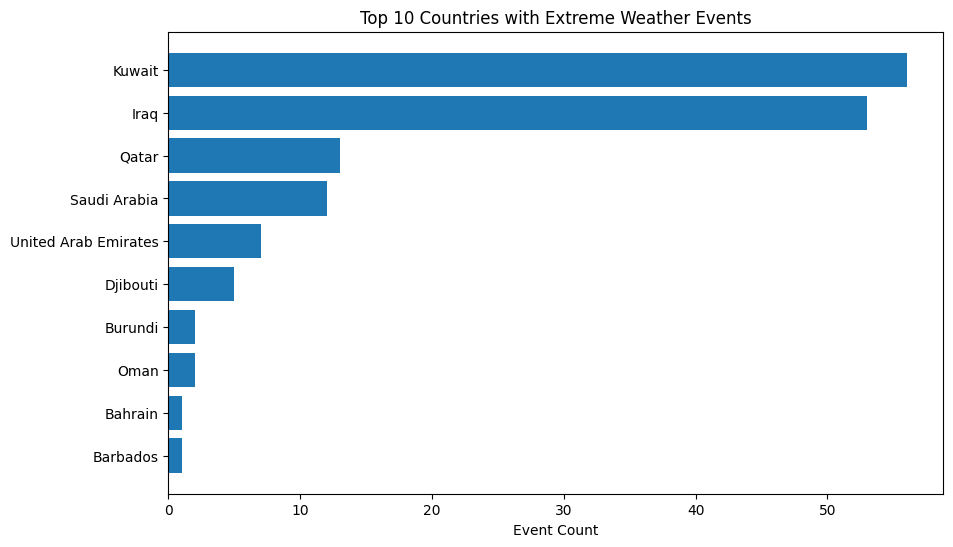

In [45]:
plt.figure(figsize=(10,6))
plt.barh(
    extreme_rank['country'].head(10),
    extreme_rank['extreme_event_count'].head(10)
)

plt.title("Top 10 Countries with Extreme Weather Events")
plt.xlabel("Event Count")
plt.gca().invert_yaxis()
plt.show()

In [31]:
country_temp = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
)

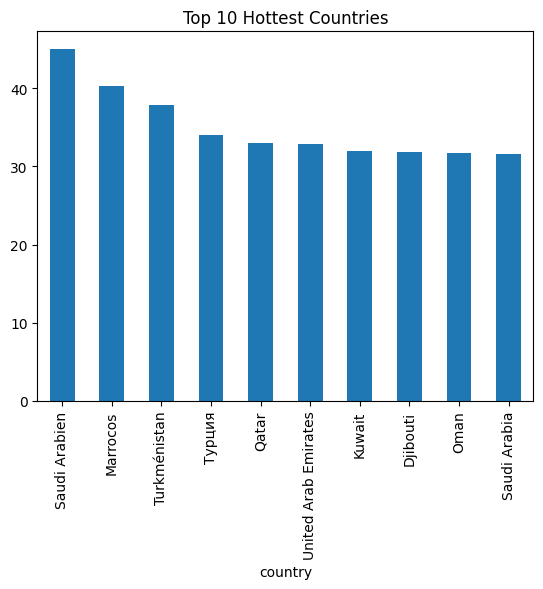

In [32]:
country_temp.head(10).plot(kind="bar")
plt.title("Top 10 Hottest Countries")
plt.show()

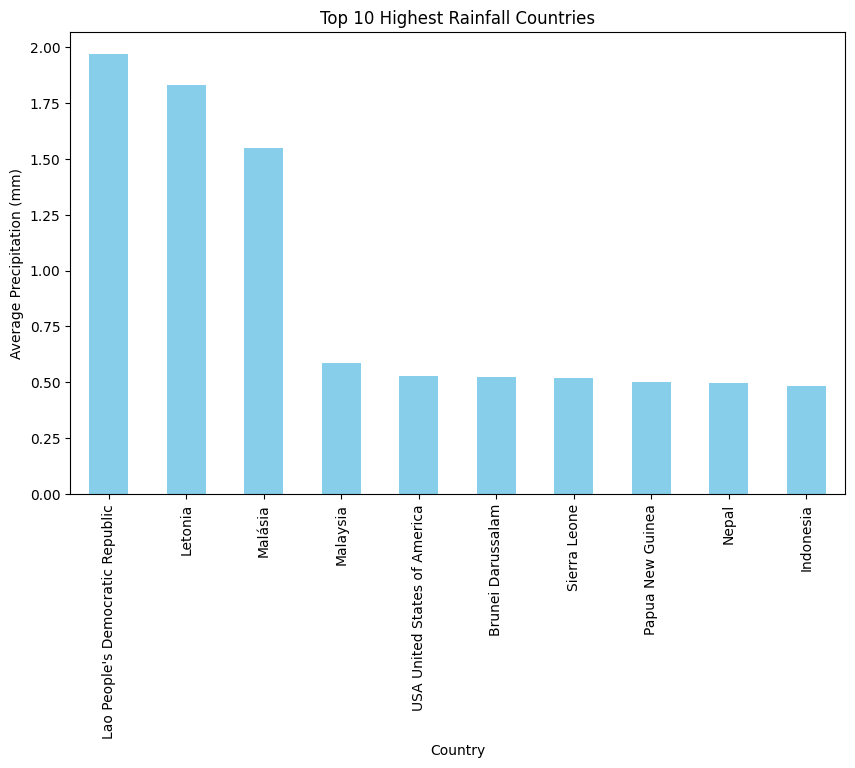

In [33]:
country_rain = (
    df.groupby("country")["precip_mm"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
country_rain.head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 Highest Rainfall Countries")
plt.xlabel("Country")
plt.ylabel("Average Precipitation (mm)")
plt.show()

In [34]:
import plotly.express as px

country_temp = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .reset_index()
)

C:\Users\LOQ\AppData\Local\Temp\ipykernel_24392\1452855774.py:1: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



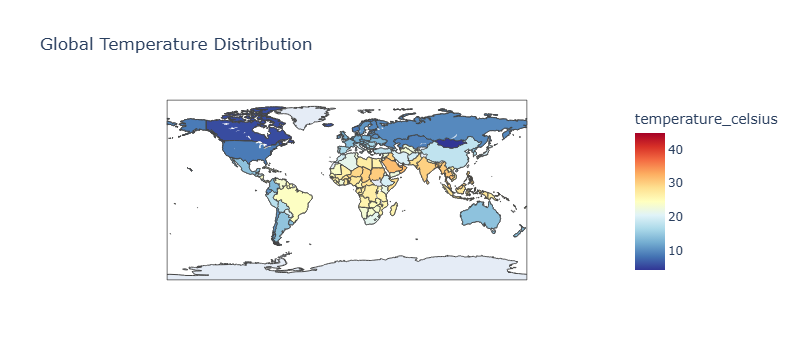

In [37]:
fig = px.choropleth(
    country_temp,
    locations="country",
    locationmode="country names",
    color="temperature_celsius",
    title="Global Temperature Distribution",
    color_continuous_scale="RdYlBu_r"
)

fig.show()